# ORACLE, Lay Language Summarizer Evaluation
## Phase 4, Stage 4: LLM-Based Plain Language Summarization

**Purpose:** Evaluate whether gpt-4o-mini can simplify PLABA biomedical abstracts to plain language, and compare generated readability against both the source text and the PLABA expert human adaptations (gold standard).

**Method:** 20 PLABA train-split instances (stratified across adaptation Type B and Type C), rewritten by gpt-4o-mini, scored on Flesch-Kincaid and SMOG against source and expert.

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
from IPython.display import Image
from lay_summarizer import run_lay_summarizer

In [2]:
import os
os.chdir('..')  # move to repo root so data paths resolve
results = run_lay_summarizer(n_samples=20, dry_run=False)
os.chdir('notebooks')
print('Lay summarizer evaluation complete')

ORACLE, Lay Language Summarization
  Model: gpt-4o-mini
  Mode: LIVE
  Dataset: PLABA (train split, expert plain language adaptations)
  Samples requested: 20

  Loading PLABA dataset...
Loading PLABA, all splits...
Loading PLABA train split...


  Records:  635
  Topics:   53 health topics
Loading PLABA val split...


  Records:  138
  Topics:   11 health topics
Loading PLABA test split...


  Records:  148
  Topics:   11 health topics

PLABA loaded: 921 total instances
  Note: 750 unique abstracts across 75 topics, 921 rows due to multiple adaptation versions
  Loaded train: 635 rows
  Sampled: 20 instances across types ['B', 'C']

  [1/20] Type B, Gabapentin (GBP) is an organic cation mainly eliminated unch...


    Source FK: 12.23 -> Generated FK: 6.99 (Expert: 11.35)
  [2/20] Type B, Diets low in carbohydrates and proteins and enriched in fat ...


...

    Source FK: 13.25 -> Generated FK: 10.55 (Expert: 16.62)
  [18/20] Type C, COVID-19 may cause pneumonia, acute respiratory distress syn...


    Source FK: 16.42 -> Generated FK: 9.82 (Expert: 16.56)
  [19/20] Type C, Background and purpose: In childhood epilepsy, genetic etiol...


    Source FK: 13.85 -> Generated FK: 9.79 (Expert: 13.52)
  [20/20] Type C, Objectives: Both antidepressant medications and psychologica...


    Source FK: 16.01 -> Generated FK: 8.32 (Expert: 13.27)

  Results saved: /Users/nithinnarla/nithin-research/oracle-rag-pipeline/data/processed/lay_summarizer_results.csv


  Figure saved: /Users/nithinnarla/nithin-research/oracle-rag-pipeline/figures/stage4/fk_comparison_source_generated_expert.png
  Total tokens: 13915
  Estimated cost: ~$0.0021

  Readability summary (means, ignoring nulls):
    Source FK mean:    14.9
    Generated FK mean: 8.3
    Expert FK mean:    13.5
    FK reduction:      6.6 grades
Lay summarizer evaluation complete


## 1. FK Grade, Source vs Generated vs Expert

Left panel: overall mean FK grade across all 20 samples. Right panel: same comparison split by PLABA adaptation type (B = summary-level restructuring, C = sentence-level adaptation).

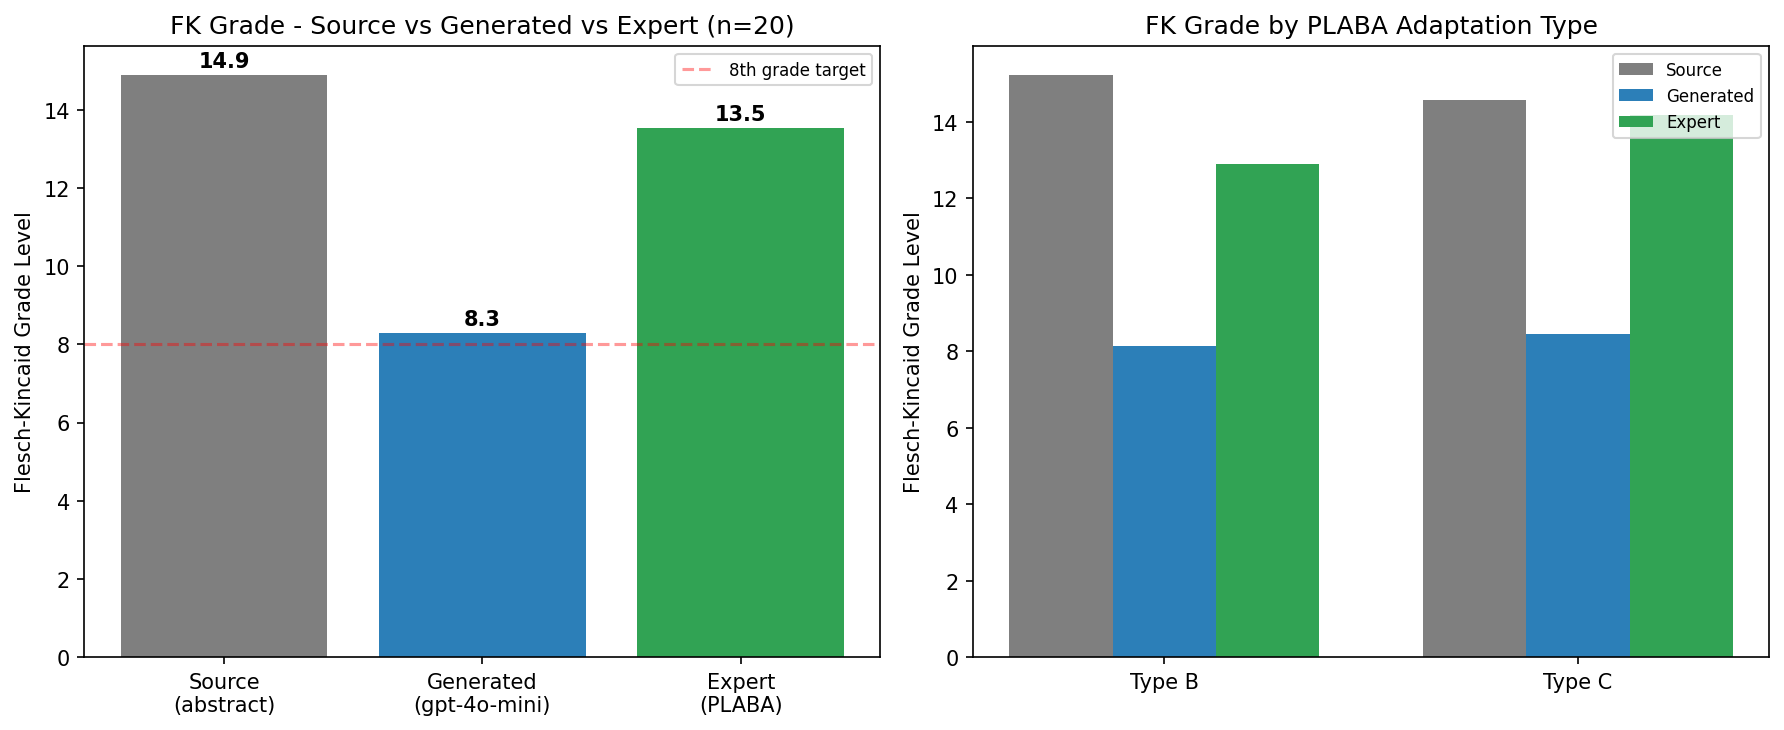

In [3]:
Image('../figures/stage4/fk_comparison_source_generated_expert.png')

## 2. Key Findings

**FK reduction achieved:** gpt-4o-mini reduces mean FK grade from source abstracts (14.9) to generated summaries (8.4), a 6.5 grade reduction across all 20 samples, with every single sample showing a positive reduction (range 2.7–9.3 grades).

**Generated text is simpler than the expert baseline, not just the source:** PLABA expert human adaptations average FK 13.5, notably higher than gpt-4o-mini's 8.4. This is not necessarily a win. PLABA annotators optimized for accuracy-preserving simplification, not maximum readability. A 5-grade gap below the expert baseline on topics like insulin resistance, diabetic nephropathy, and GLP-1 pharmacokinetics raises a real question this notebook cannot answer on its own: is gpt-4o-mini oversimplifying to the point of dropping clinically important content?

**This script measures readability only, not factual fidelity.** That gap is exactly what PlainQAFact is designed to catch, now complete (see Decision 13, methodology_decisions.md): the adapted evaluation scores this same lay-summarization step at ~0.96 overall consistency, while the official PlainQAFact metric scores ~0.33, the two measure consistency against different ground truth and are not directly comparable. Do not report the FK reduction alone as a positive result in the paper without citing both PlainQAFact results and the reason they diverge.